In [ ]:
import marimo as mo

# EE446 - TinyML - Assignment 2

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-08-12 23:07:00.315286: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-12 23:07:00.336486: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-12 23:07:00.336512: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-12 23:07:00.336533: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-12 23:07:00.341227: I tensorflow/core/platform/cpu_feature_g

## Reading Data

In [ ]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [ ]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [ ]:
# (a) drop the four requested columns in place
data.drop(['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'], axis=1, inplace=True)
print(data.shape)

(125973, 39)


##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [ ]:
# (b) binarize the label: everything that is not "normal" becomes "attack"
data.loc[data['attack'] != 'normal', 'attack'] = 'attack'
cat_cols = ['protocoltype', 'service', 'flag', 'attack']
print(data['attack'].value_counts())

attack
normal    67343
attack    58630
Name: count, dtype: int64


In [ ]:
data

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [ ]:
# (c) label-encode the non-numerical columns (attack -> 0, normal -> 1)
for _col in cat_cols:
    data[_col] = LabelEncoder().fit_transform(data[_col])
print(data[cat_cols].dtypes)

protocoltype    int64
service         int64
flag            int64
attack          int64
dtype: object


In [ ]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [ ]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

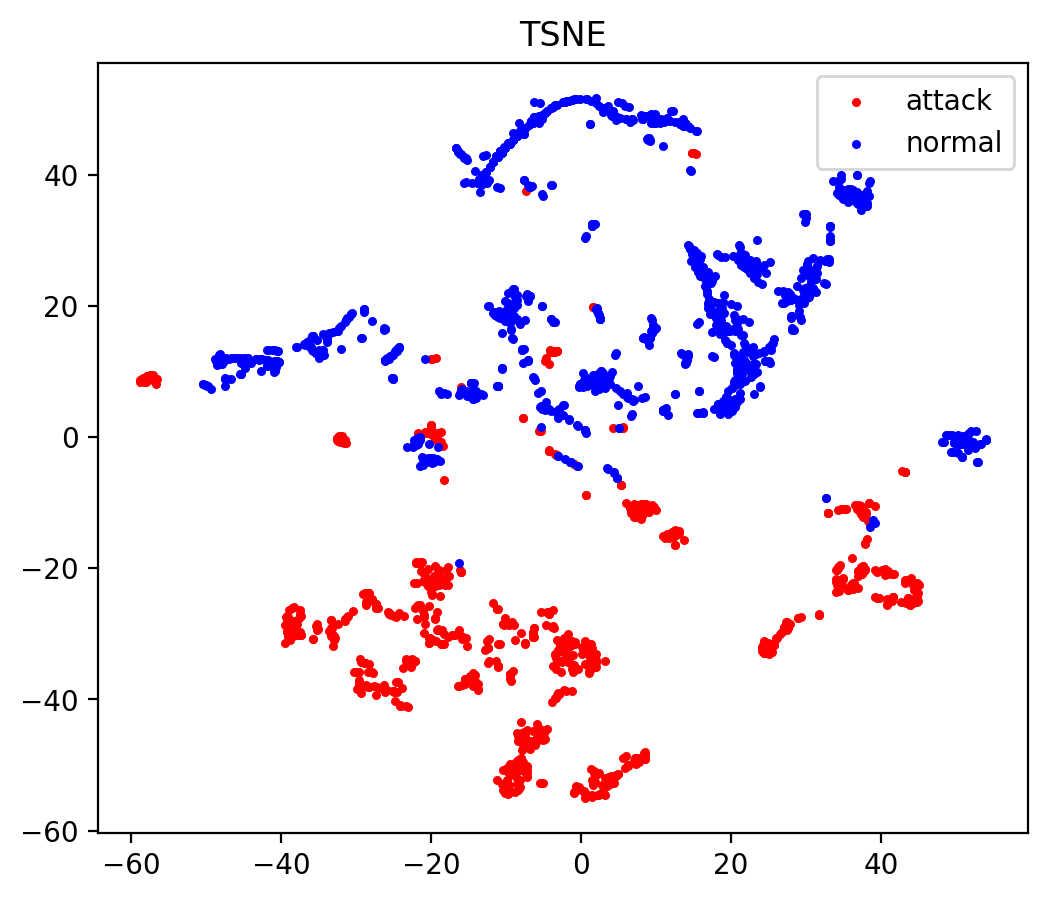

In [ ]:
from sklearn.manifold import TSNE

# t-SNE and kernel PCA are O(n^2), so use a random 2000-point subsample of the test set
_rng = np.random.default_rng(0)
sub = _rng.choice(len(X_test), 2000, replace=False)
X_sub, y_sub = X_test[sub], y_test[sub].ravel()

def plot_2d(Z, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(Z[y_sub == 0, 0], Z[y_sub == 0, 1], c='red', s=5, label='attack')
    ax.scatter(Z[y_sub == 1, 0], Z[y_sub == 1, 1], c='blue', s=5, label='normal')
    ax.set_title(title)
    ax.legend()
    fig.savefig('../assets/' + title.lower().replace('-', '') + '.png', dpi=120, bbox_inches='tight')
    return fig

plot_2d(TSNE(n_components=2, random_state=0).fit_transform(X_sub), 'TSNE')

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

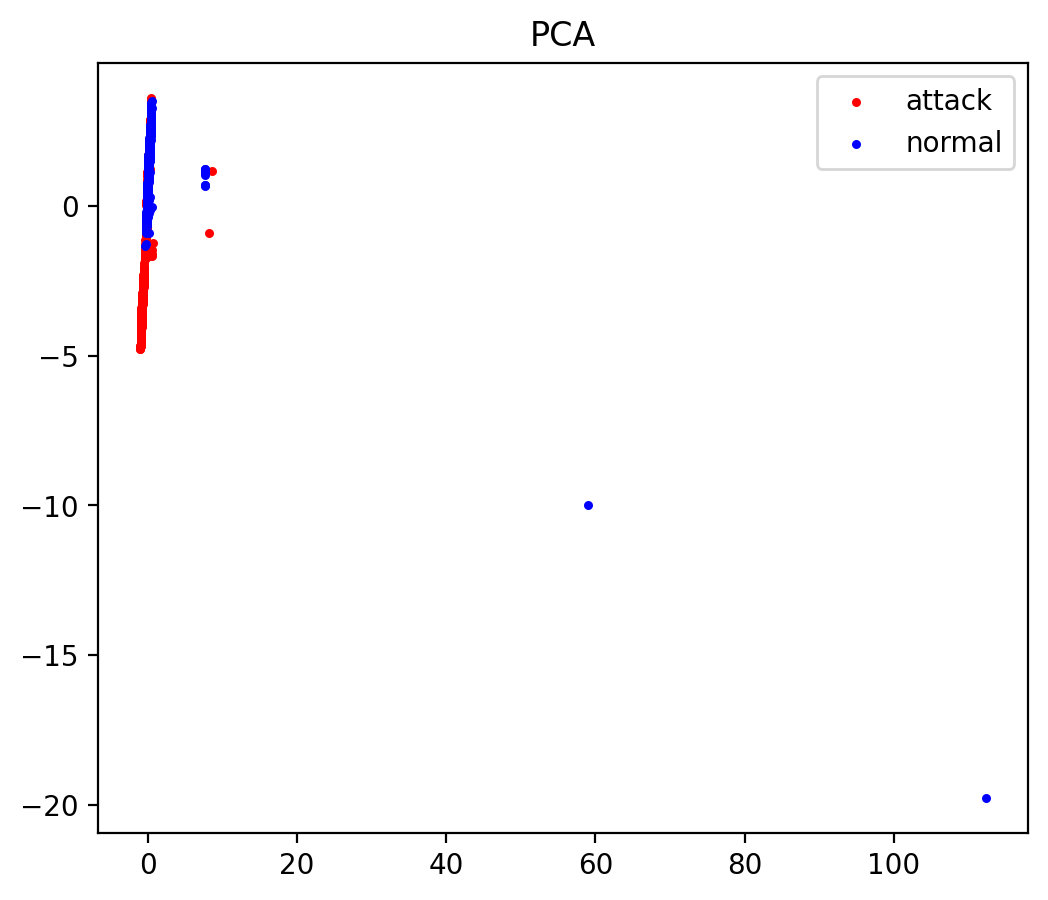

In [ ]:
from sklearn.decomposition import PCA

plot_2d(PCA(n_components=2).fit_transform(X_sub), 'PCA')

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

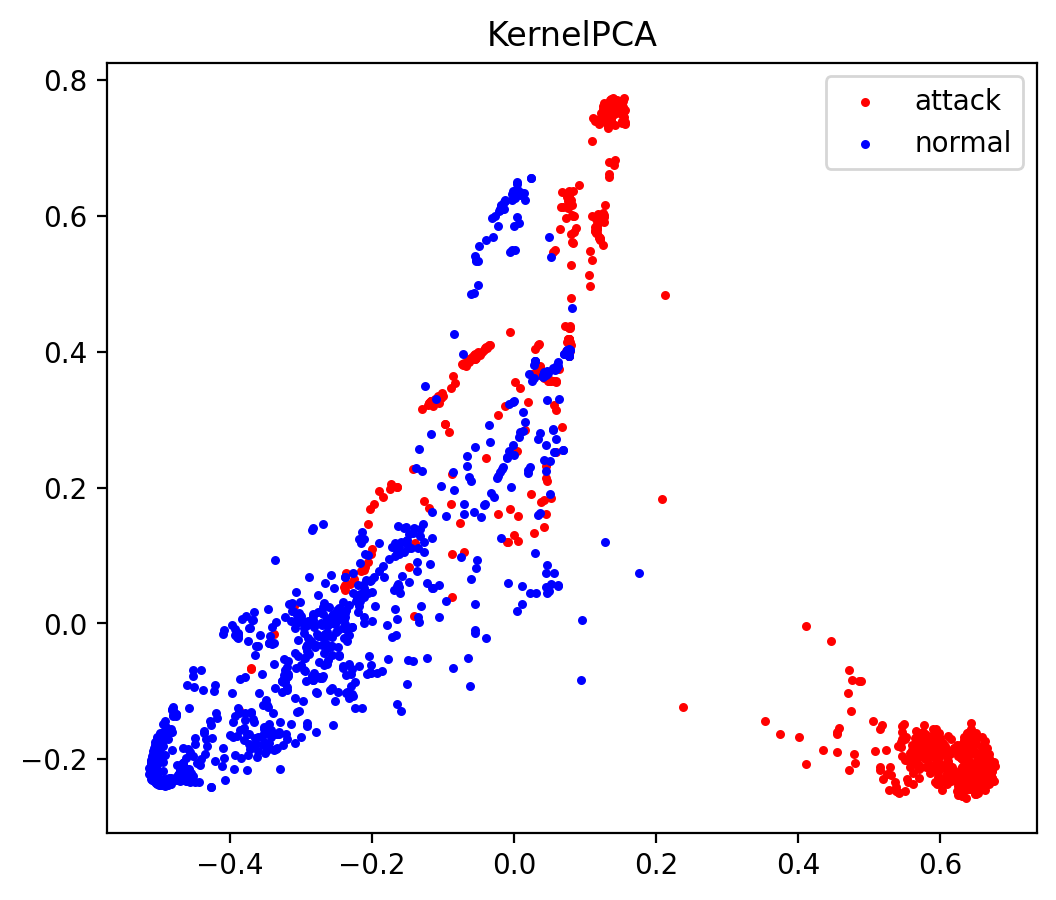

In [ ]:
from sklearn.decomposition import KernelPCA

plot_2d(KernelPCA(n_components=2, kernel='rbf').fit_transform(X_sub), 'KernelPCA')

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure that the output layer contains one neuron with sigmoid activation.

In [ ]:
# Define the DNN model
base_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
base_model.summary()

2026-08-12 23:07:05.892286: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2496      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 5121 (20.00 KB)
Trainable params: 5121 (20.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [ ]:
base_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
base_model.fit(X_train, y_train, epochs=10, batch_size=256, validation_split=0.1, verbose=2)

Epoch 1/10


2026-08-12 23:07:06.959278: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-08-12 23:07:07.353930: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f3f703abc80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-12 23:07:07.353951: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-08-12 23:07:07.357987: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-12 23:07:07.371124: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-08-12 23:07:07.425646: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


355/355 - 3s - loss: 0.0826 - accuracy: 0.9726 - val_loss: 0.0196 - val_accuracy: 0.9934 - 3s/epoch - 9ms/step
Epoch 2/10
355/355 - 2s - loss: 0.0147 - accuracy: 0.9955 - val_loss: 0.0118 - val_accuracy: 0.9952 - 2s/epoch - 5ms/step
Epoch 3/10
355/355 - 1s - loss: 0.0098 - accuracy: 0.9965 - val_loss: 0.0110 - val_accuracy: 0.9964 - 977ms/epoch - 3ms/step
Epoch 4/10
355/355 - 1s - loss: 0.0081 - accuracy: 0.9970 - val_loss: 0.0093 - val_accuracy: 0.9967 - 1s/epoch - 3ms/step
Epoch 5/10
355/355 - 1s - loss: 0.0073 - accuracy: 0.9971 - val_loss: 0.0090 - val_accuracy: 0.9968 - 1s/epoch - 4ms/step
Epoch 6/10
355/355 - 1s - loss: 0.0061 - accuracy: 0.9977 - val_loss: 0.0076 - val_accuracy: 0.9976 - 920ms/epoch - 3ms/step
Epoch 7/10
355/355 - 1s - loss: 0.0055 - accuracy: 0.9980 - val_loss: 0.0074 - val_accuracy: 0.9967 - 927ms/epoch - 3ms/step
Epoch 8/10
355/355 - 1s - loss: 0.0055 - accuracy: 0.9979 - val_loss: 0.0080 - val_accuracy: 0.9967 - 900ms/epoch - 3ms/step
Epoch 9/10
355/355 - 1s

<keras.src.callbacks.History object at 0x7f3f84d495d0>

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

In [ ]:
y_pred = (base_model.predict(X_test, verbose=0) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['attack', 'normal']))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11688
      normal       1.00      1.00      1.00     13507

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

[[11680     8]
 [   30 13477]]


In [ ]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement full-integer INT8 post-training quantization on the base_model. Use a representative dataset from X_train to calibrate the activation ranges. Configure the converter to use INT8 operators with INT8 input and output tensors. Designate the resulting quantized model as tflite_quant_model.

In [ ]:
# Load the trained model
base_model_1 = tf.keras.models.load_model('original_model.h5')

def representative_dataset():
    # calibrate activation ranges on a slice of the training set
    for _x in X_train[:500].astype(np.float32):
        yield [_x.reshape(1, -1)]

converter = tf.lite.TFLiteConverter.from_keras_model(base_model_1)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_quant_model = converter.convert()

2026-08-12 23:07:21.348338: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-08-12 23:07:21.348368: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-08-12 23:07:21.348726: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp5zw3qc2y
2026-08-12 23:07:21.349638: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-08-12 23:07:21.349647: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp5zw3qc2y
2026-08-12 23:07:21.351785: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-08-12 23:07:21.352263: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-08-12 23:07:21.377982: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp5zw3qc2y
2026-08

In [ ]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 100.01 KB
Quantized model size: 8.24 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

In [ ]:
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()
in_det = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]
in_scale, in_zp = in_det['quantization']
out_scale, out_zp = out_det['quantization']
print(f"input scale={in_scale}, zero_point={in_zp}")

y_pred_quant = np.empty((len(X_test), 1), dtype=int)
for _i, _x in enumerate(X_test):
    # quantize the sample with the input tensor's scale and zero point
    _xq = np.clip(np.round(_x / in_scale) + in_zp, -128, 127).astype(np.int8)
    interpreter.set_tensor(in_det['index'], _xq.reshape(1, -1))
    interpreter.invoke()
    _out = interpreter.get_tensor(out_det['index'])[0][0]
    y_pred_quant[_i] = ((_out - out_zp) * out_scale) > 0.5

print(classification_report(y_test, y_pred_quant, target_names=['attack', 'normal']))
print(confusion_matrix(y_test, y_pred_quant))

input scale=0.11214608699083328, zero_point=-52


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11688
      normal       1.00      1.00      1.00     13507

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

[[11681     7]
 [   42 13465]]


## Converting tflite_quant_model to C and creating the header file

In [ ]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [ ]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [ ]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, 2.2496402596904983, 
    -0.7362346401101137, -0.00776224074056876, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    0.3221818209983339, -0.24420394625771188, 1.602663889932865, 
    1.6051037177847889, -0.37436223991967527, -0.37443160310530493, 
    -1.3214280114927377, -0.016929597707948767, -0.37455970440553465, 
    0.7343425609306344, -0.9543885148106975, -1.0719329252940557, 
    -0.17441734820805624, -0.4801968475158174, -0.28910340026287856, 
    1.6087590765792643, 1.6189552037455606, -0.38763462350750655, 
    -0.3763870260680415, -0.21997021516886575, -0.11024922

In [ ]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    0, 0, 0, 1, 0
};



##### Question 5 (d): ten more samples, excluding the first five

In [ ]:
Xtest10 = X_test[5:15,:]
print(c_writer.create_array(Xtest10,"float","X_test"))

const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.6867852074966913, 
    0.7511112872365361, -0.007696997143860383, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7170454919159579, -0.35434285002584825, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    -1.402628854168409, -0.3852946548873903, -1.0051099793265696, 
    0.03731130769783004, -0.25365662769412595, -0.02258683123335326, 
    -0.6395319051152512, -0.6248707997445304, -0.32239374008094723, 
    -0.3763870260680415, 0.21642633142264128, -0.1102

In [ ]:
ytest10 = y_test[5:15].ravel()
print(c_writer.create_array(ytest10,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 10;

const uint8_t y_test[10] = {
    1, 1, 1, 1, 1, 1, 1, 1, 0, 0
};

